# **CNN: Convolutional Neural Network:**
It is used for Image Recognization /Image Detection

**Pre-Requisites : -**
1. Python
2. opencv
3. tensorflow with keras

**There are 3 main layers in CNN**
1. Convolutional layer
2. Relu Layer   (concept :   if X<0 then 0 else if X>=0 then X
3. Pooling Layer
  - There are 3 types of pooling layers
    1. max pooling  : mostly used this pooling
    2. average pooling
    3. sum pooling

**Application of CNN**
  - Image Recognition
  - Image Classification
  - Object Detection
  - face Recognition

**Type of NN**
1. **ANN**: Artificial Neural Network --> work on structure data
2. **CNN**: Convolution NN --> work on Image
- **Application of CNN**
  - Image Recognition
  - Image Classification
  - Object Detection
  - face Recognition


In [ ]:
# import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import cv2
import tensorflow as tf

from google.colab.patches import cv2_imshow

**fashion_mnist:** inbuild dataset
- Take inbuild dataset which hold image: Classification datasets
- Multiclass Classifier --> Total 10 classes (0-9)

The fashion MNIST dataset is a popular dataset used in ML and DL for Image Classification Task.

- **Type** : Image Classifiaction dataset
- **Total Images**: 70000(Total training set: 60000 and testing set: 10000)
- **Image Details:**
  - Image Size: 28*28 pixels

Each Image Represent a fashion product --> Classes (Labels)

**There are 10 category:**

|Label|Class Name|
|-----|----------|
|0|T-shirt/Top|
|1|Trouser|
|2|Pullover|
|3|Dress|
|4|Coat|
|5|Sandal|
|6|Shirt|
|7|Sneaker|
|8|Bag|
|9|Ankle Boot|

In [ ]:
# To Load inbuild dataset; use method load_data()
# load_data() --> define in

(xtrain,ytrain),(xtest,ytest) = tf.keras.datasets.fashion_mnist.load_data() # split are inbuild

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


In [ ]:
xtrain.shape,ytrain.shape,xtest.shape,ytest.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
xtrain

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
xtrain[0] # show 1st image(0th index) from xtrain
# gray scale image (min= 0, max=255)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [ ]:
# check dimension
xtrain.ndim

3

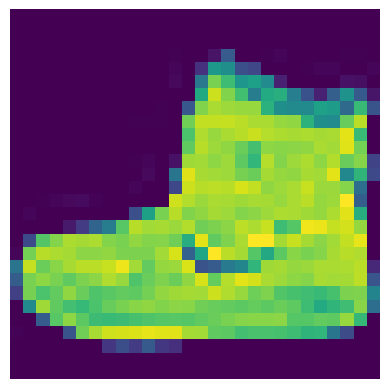

In [ ]:
# to show 1st image from traing data
plt.imshow(xtrain[0])
plt.axis("off")
plt.show()

In [ ]:
for i in range(0,10):
  cv2_imshow(xtrain[i])

In [ ]:
# check category : To check 1st image belong to which category
ytrain[0]

# in loop
# for i in range(0,10):
#   print(ytrain[i])

np.uint8(9)

In [ ]:
# Create the list of the category

Category = ["T-shirt/Top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle Boot"]
print(Category)

['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


In [ ]:
for i,v in enumerate(Category):
  print(i,v)

0 T-shirt/Top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle Boot


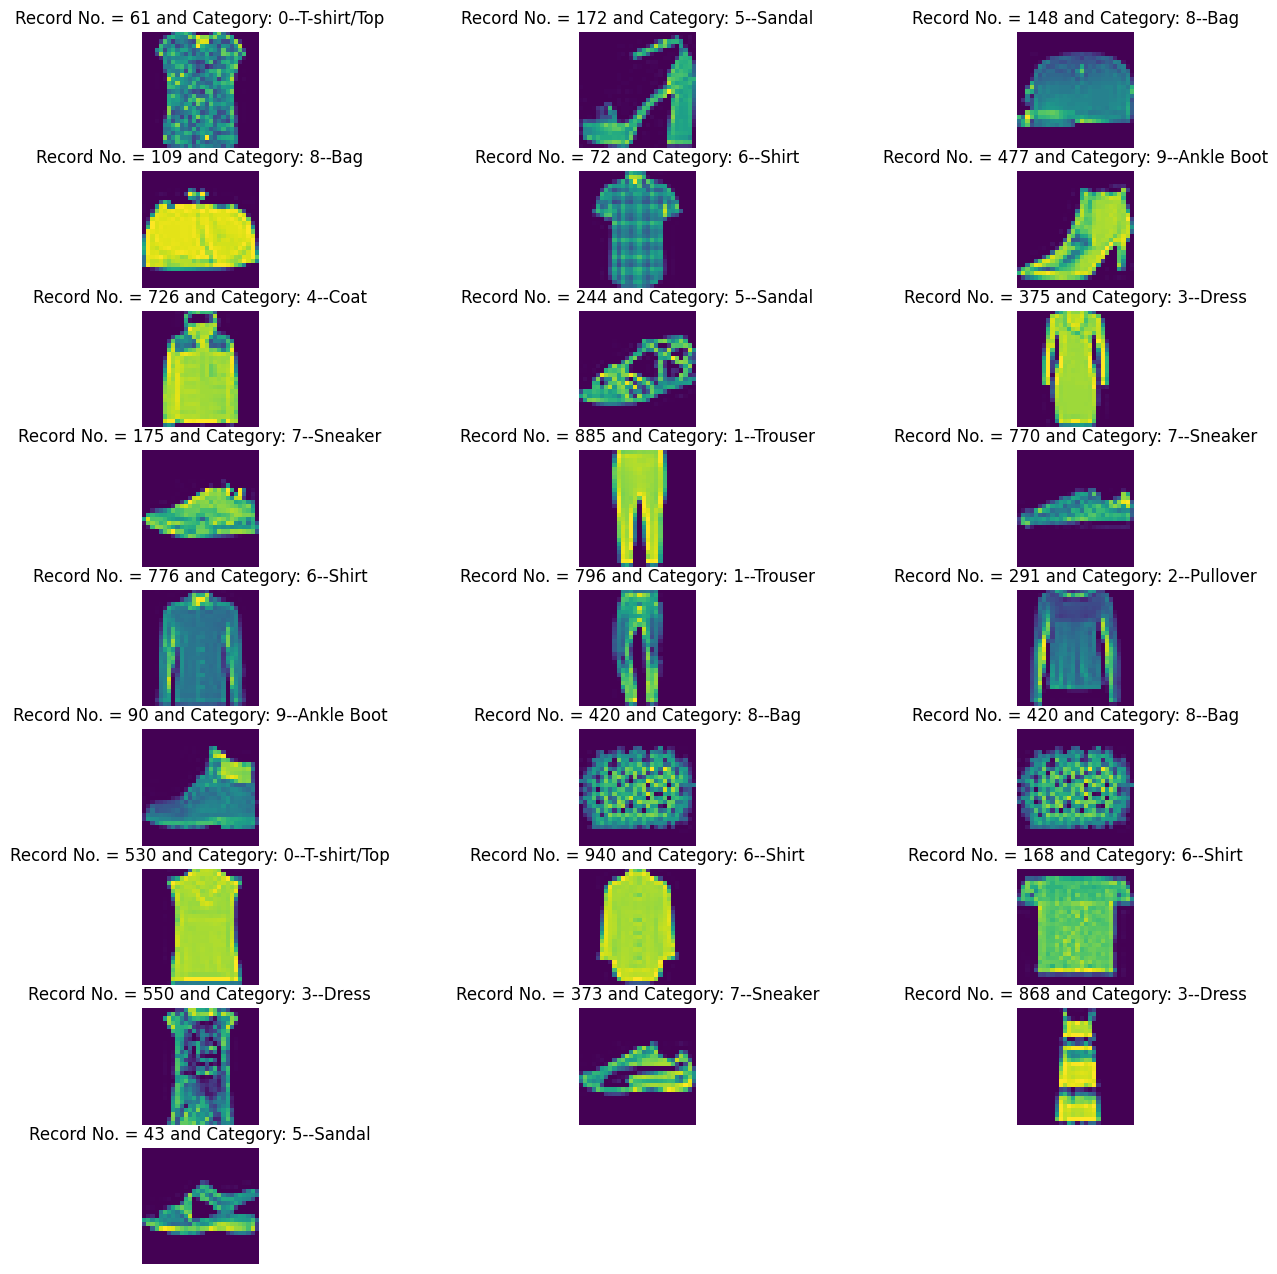

In [ ]:
# To show random 25 images from 1st - 1000 iamge from xtrain(training  image)

plt.figure(figsize=(16,16))
j = 1 # frame

for i in np.random.randint(0,1000,25):
  # firts create a frame
  plt.subplot(9,3,j); j=j+1 # 9--> no.of row, 3--> no.of columns, j--> no.of frame
  plt.imshow(xtrain[i])
  plt.axis("off")
  plt.title(f"Record No. = {i} and Category: {ytrain[i]}--{Category[ytrain[i]]}")

In [ ]:
# compulsory:  Required 4D image in CNN
# but we have 3D image

# check Dimension
xtrain.ndim, xtest.ndim

(3, 3)

In [ ]:
xtrain.shape

(60000, 28, 28)

In [ ]:
# convert 3D image (input) into 4D, use inbuild method
# expand_dims() which define in numoy library

# 1st increase dimension of training input image xtrain from 3D -> 4D
xtrain = np.expand_dims(xtrain,axis = -1)     # axis = -1 means add dimension in left side

# similarly increase dimension of testing input from 3D -> 4D
xtest = np.expand_dims(xtest,axis = -1)     # axis = -1 means add dimension in left side

In [ ]:
xtrain.shape

(60000, 28, 28, 1)

In [ ]:
xtest.shape

(10000, 28, 28, 1)

In [ ]:
xtrain.min(),xtrain.max()

# apply MinMaxScaler: formula: (X - Xmin/ Xmax - Xmin)
# xtrain = xtrain-0/(255-0)
# xtrain = xtrain/255

# apply feature scaling: here use MinMaxScaler means Normalised
xtrain = xtrain/255
xtest = xtest/255

In [ ]:
xtrain.min(),xtrain.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
xtest.min(), xtest.max()

(np.float64(0.0), np.float64(1.0))

**Model build with the CNN**
1. Convolution Layer: Select Important Feature from given images
2. relu Activation
3. Pooling Layer: here use max pooling
4. Convert to 1D
5. Use ANN

In [ ]:
# use Sequential class: inbuild class which define in tf.keras
# create the object of Sequential class and passing the following parameters
# ilters=128 (max)
Model =tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides = (1,1),padding="valid",activation="relu", input_shape=[28,28,1]),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),  #convet 2D array into 1D
    tf.keras.layers.Dense(units = 785, activation= "relu"),  # hidden layer --> 28*28 + 1 = 785
    tf.keras.layers.Dense(units= 10, activation="softmax")   # output layer --> multi classification
])

In [ ]:
# compile model
Model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# if we have 2class --> binary_crossentropy
# if we have more than 2 classes --> spare_categorical_crossentropy
# if we have cobtinuous numeric we will use --> mse

In [ ]:
# procedure for early  stoping

from tensorflow.keras.callbacks import EarlyStopping
# create the object of early stopping class

es = EarlyStopping(monitor = "val_loss",   # monitribg testing loss
                  min_delta = 0.0001,      # standrd reading affter research
                  patience = 20,
                  verbose = 1,
                  baseline = None,         # weight and bias should be taken as afresher not from the 1st interate
                  restore_best_weights = False)

In [ ]:
# train the model with 70% training input and traing output
#  use inbuild method fit()
# epochs --> how many iteration
TrainedModel = Model.fit(xtrain, ytrain, epochs = 1000, batch_size = 32, callbacks = es, validation_data = (xtest,ytest))

Epoch 1/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9884 - loss: 0.0330 - val_accuracy: 0.9125 - val_loss: 0.4409
Epoch 2/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0264 - val_accuracy: 0.9158 - val_loss: 0.4339
Epoch 3/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0234 - val_accuracy: 0.9149 - val_loss: 0.4832
Epoch 4/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0221 - val_accuracy: 0.9007 - val_loss: 0.6052
Epoch 5/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9929 - loss: 0.0204 - val_accuracy: 0.9101 - val_loss: 0.5749
Epoch 6/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9932 - loss: 0.0196 - val_accuracy: 0.9099 - val_loss: 0.5621
Epoch 7/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.9156 - val_loss: 0.5645
Epoch 8/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9939 -

In [ ]:
# test the model with 30% testing input
ypred = Model.predict(xtest).round(2)
ypred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
# highest probability
ypred = [np.argmax(i) for i in ypred]  # argmax() inbuild method of numpy, it is return index of highest item in given list
ypred

[np.int64(9),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(4),
 np.int64(6),
 np.int64(5),
 np.int64(7),
 np.int64(4),
 np.int64(5),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(1),
 np.int64(2),
 np.int64(6),
 np.int64(8),
 np.int64(0),
 np.int64(2),
 np.int64(5),
 np.int64(7),
 np.int64(5),
 np.int64(1),
 np.int64(4),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(3),
 np.int64(3),
 np.int64(8),
 np.int64(0),
 np.int64(7),
 np.int64(5),
 np.int64(7),
 np.int64(9),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(7),
 np.int64(6),
 np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(4),
 np.int64(6),
 np.int64(5),
 np.int64(8),
 np.int64(2),
 np.int64(2),
 np.int64(8),
 np.int64(4),
 np.int64(8),
 np.int64(0),
 np.int64(7),
 np.int64(7),
 np.int64(8),
 np.int64(5),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(7),
 np.int64(8),
 np.int64(7),
 np.in

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:

cm = confusion_matrix(ytest,ypred)
cm

array([[850,   1,  14,  21,   6,   1, 100,   1,   6,   0],
       [  0, 985,   4,   6,   2,   0,   1,   0,   2,   0],
       [ 20,   1, 847,  13,  50,   0,  66,   0,   3,   0],
       [ 17,   7,   5, 922,  12,   0,  32,   0,   4,   1],
       [  2,   0,  71,  26, 830,   0,  68,   0,   3,   0],
       [  0,   0,   0,   0,   0, 973,   0,  21,   1,   5],
       [ 88,   4,  53,  19,  30,   0, 792,   0,  14,   0],
       [  1,   0,   0,   0,   0,   4,   0, 980,   0,  15],
       [  2,   2,   2,   4,   0,   1,   2,   2, 985,   0],
       [  0,   0,   0,   0,   0,   6,   0,  30,   2, 962]])

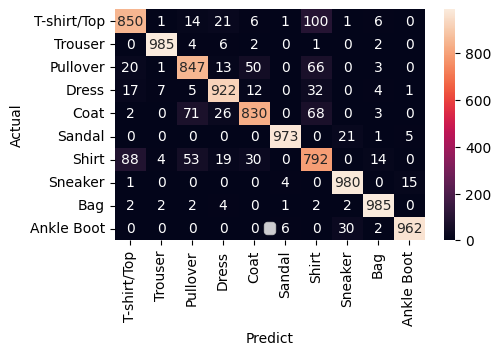

In [ ]:
plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,fmt="d", xticklabels=Category, yticklabels=Category)

# fmt --> format -> d means --> int
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.legend()
plt.show()

In [ ]:
cr = classification_report(ytest,ypred)
print(cr)

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1000
           1       0.98      0.98      0.98      1000
           2       0.85      0.85      0.85      1000
           3       0.91      0.92      0.92      1000
           4       0.89      0.83      0.86      1000
           5       0.99      0.97      0.98      1000
           6       0.75      0.79      0.77      1000
           7       0.95      0.98      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
# Model.evaluate(xtest, ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9126 - loss: 0.8664


[0.866383969783783, 0.9125999808311462]